# BT4222 Case Study: Feature Engineering on Amazon Review data

According to a survey received from former students of BT4222, it has been noted that data preprocessing presented significant challenges in their projects. In response to this, we have developed a comprehensive series of data preprocessing tasks, utilizing actual datasets from [Amazon Data 2018](https://cseweb.ucsd.edu/~jmcauley/datasets/amazon_v2/).

Note: we only present very **preliminary** solutions on data preprocessing and  feature engineering. They may not present the best solutions but serve as the **starting points** for your critical thinking and further exploration.

**Question**
*Any critiques about data leakage issue with this case study?
How should you avoid data leakage in training your model?*

### Amazon Review Dataset Information

The [Amazon Review Data (5-core)](https://cseweb.ucsd.edu/~jmcauley/datasets/amazon_v2/#subsets) contains review data for individual products, reduced to extract the 5-core, ensuring that each of the remaining users and items have 5 reviews each.

- **overall**: Rating of the product.
- **verified:** Indicates whether the user is verified.
- **reviewTime:** Datetime of the review in raw format. (e.g., 09 1, 2016)
- **reviewerID:** ID of the reviewer (e.g., A2SUAM1J3GNN3B).
- **asin:** ID of the product (e.g., 0000013714).
- **style:** A dictionary of product metadata. (e.g., {'Size:': ' 7.0 oz', 'Flavor:': ' Classic Ice Blue'})
- **reviewerName:** Name of the reviewer.
- **reviewText:** Text of the review.
- **summary:** Summary of the review.
- **unixReviewTime:** Time of the review in Unix time.
- **vote:** Helpful votes of the review.
- **image:** Image links posted after receiving the product.

### Amazon Meta Dataset Information

The [Amazon Meta Data (complete)](https://cseweb.ucsd.edu/~jmcauley/datasets/amazon_v2/#complete-data) includes meta information for individual products, such as description, price, sales rank, brand info, and co-purchasing links.

- **category:** List of categories the product belongs to.
- **tech1:** The first tech detail table of the product.
- **description:** Description of the product.
- **fit:** The fit of the product.
- **title:** Name of the product.
- **also_buy:** Related products also bought.
- **tech2:** The second tech detail table of the product.
- **brand:** Brand name.
- **feature:** Bullet-point format features of the product.
- **rank:** Sales rank information.
- **also_view:** Related products also viewed.
- **details:** Product details.
- **main_cat:** Category of product.
- **similar_item:** Similar product table.
- **date:** Date first available (at time of crawl).
- **price:** Price in US dollars (at time of crawl).
- **asin:** ID of the product (e.g., 0000031852).
- **imageURL:** URL of the product image.
- **imageURLHighRes:** URL of the high-resolution product image.

### Import Packages Needed

In [ ]:
import os
import json
import gdown
import pandas as pd
import numpy as np
### Plot
import matplotlib.pyplot as plt
import seaborn as sns
### HTML
from bs4 import BeautifulSoup
import re
### Warnings
import warnings
### Text Preprocessing and Natural Language Processing
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk import pos_tag
from nltk.stem import WordNetLemmatizer
import nltk
import re
import spacy
from wordcloud import WordCloud

### Download Data Files Needed

 For this assignment, we will work with data from the Beauty and Fashion categories, thus there are 2 review data files and 2 metadata files.

In [ ]:
# Set the file names and IDs
# For Amazon Reivew Data
review_file_ids = {
    'All_Beauty_5.json',
    'AMAZON_FASHION_5.json'
}

# For Amazon Meta Data
meta_file_ids = {
    'meta_All_Beauty.json',
    'meta_AMAZON_FASHION.json',
}


In [ ]:
from google.colab import drive
### Permit this notebook to access your Google Drive files?
### Please select "Connect to Google Drive", choose your account and select continue
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
### adjust the data directory if needed
### For example, here we created a "amazon_review" Folder for this assignment
### in Google Drive and put the data files needed under the "data" subfolder
%cd /content/drive/My Drive/amazon_review/

/content/drive/My Drive/amazon_review


## Task 1 - Data Loading

Load the Amazon Review Data files (**All_Beauty_5.json** and **AMAZON_FASHION_5.json** in `review_file_ids`) into a pandas DataFrame `review_df_raw`:

1. Initialize an empty list `review_data` to store the review data.
2. Iterate through the files in `review_file_ids`.
3. For each file, read and append the JSON data to the review_data using `json.loads()` and `line.strp()`.
4. Create the DataFrame `review_df_raw` from `review_data` list.

Similarly, load the Amazon Meta Data files (**meta_All_Beauty.json** and **meta_AMAZON_FASHION.json** in `meta_file_ids`) into a pandas DataFrame `meta_df_raw` ad check the shapes of both DataFrames.

In [ ]:
# Initialize an empty list to store the review data
review_data = []

for filename in review_file_ids:
    # Read and append JSON data to the review_data (0.1 marks)
    with open(filename) as f:
        for line in f:
            review_data.append(json.loads(line.strip()))

# Create a DataFrame from the review_data
review_df_raw = pd.DataFrame(review_data)
print("Dataframe Shape:", review_df_raw.shape)
review_df_raw.head(3)

Dataframe Shape: (8445, 12)


,overall,verified,reviewTime,reviewerID,asin,style,reviewerName,reviewText,summary,unixReviewTime,vote,image
0,5.0,True,"09 1, 2016",A3CIUOJXQ5VDQ2,B0000530HU,"{'Size:': ' 7.0 oz', 'Flavor:': ' Classic Ice ...",Shelly F,As advertised. Reasonably priced,Five Stars,1472688000,NaN,NaN
1,5.0,True,"11 14, 2013",A3H7T87S984REU,B0000530HU,"{'Size:': ' 7.0 oz', 'Flavor:': ' Classic Ice ...",houserules18,Like the oder and the feel when I put it on my...,Good for the face,1384387200,NaN,NaN
2,1.0,True,"08 18, 2013",A3J034YH7UG4KT,B0000530HU,"{'Size:': ' 7.0 oz', 'Flavor:': ' Classic Ice ...",Adam,I bought this to smell nice after I shave. Wh...,Smells awful,1376784000,NaN,NaN


In [ ]:
# Initialize an empty list to store the meta data
meta_data = []

for filename in meta_file_ids:
    # Read and append JSON data to the meta_data (0.1 marks)
    with open(filename) as f:
        for line in f:
            meta_data.append(json.loads(line.strip()))

# Create a DataFrame from the meta_data
meta_df_raw = pd.DataFrame(meta_data)
print("Dataframe Shape:", meta_df_raw.shape)
meta_df_raw.head(3)

Dataframe Shape: (219529, 19)


,category,tech1,description,fit,title,also_buy,tech2,brand,feature,rank,also_view,details,main_cat,similar_item,date,price,asin,imageURL,imageURLHighRes
0,[],,[Loud 'N Clear Personal Sound Amplifier allows...,,Loud 'N Clear&trade; Personal Sound Amplifier,[],,idea village,[],"2,938,573 in Beauty & Personal Care (",[],{'ASIN: ': '6546546450'},All Beauty,,,,6546546450,[],[]
1,[],,[No7 Lift & Luminate Triple Action Serum 50ml ...,,No7 Lift &amp; Luminate Triple Action Serum 50...,"[B01E7LCSL6, B008X5RVME]",,,[],"872,854 in Beauty & Personal Care (",[],"{'Shipping Weight:': '0.3 ounces (', 'ASIN: ':...",All Beauty,"class=""a-bordered a-horizontal-stripes a-spa...",,$44.99,7178680776,[],[]
2,[],,[No7 Stay Perfect Foundation now stays perfect...,,No7 Stay Perfect Foundation Cool Vanilla by No7,[],,No7,[],"956,696 in Beauty & Personal Care (","[B01B8BR0O8, B01B8BR0NO, B014MHXXM8]","{'Shipping Weight:': '3.5 ounces (', 'ASIN: ':...",All Beauty,,,$28.76,7250468162,[],[]


## Task 2 - Remove Duplicate Rows

In this assignment, we will only consider the following columns for each dataframe.
- Review Data: overall, reviewTime, reviewerID, asin, reviewText, vote.
- Meta Data: fit, title, price, asin.

1. Create two new DataFrames (`review_df` and `meta_df`) by selecting the specifc columns mentioned above from the original DataFrames `review_df_raw` and `meta_df_raw`.
2. Drop duplicate rows from each dataframe and reset the index.

In [ ]:
### review_df (0.1 marks)
# Create a new DataFrame by selecting specific columns from the original DataFrame
review_df = review_df_raw[['overall', 'reviewTime', 'reviewerID', 'asin', 'reviewText', 'vote']].copy()

# Drop duplicate rows (0.1 marks)
review_df.drop_duplicates(inplace=True)

# Reset the index
review_df.reset_index(drop=True, inplace=True)

print(review_df.shape)
review_df.head(3)

(7309, 6)


,overall,reviewTime,reviewerID,asin,reviewText,vote
0,5.0,"09 1, 2016",A3CIUOJXQ5VDQ2,B0000530HU,As advertised. Reasonably priced,NaN
1,5.0,"11 14, 2013",A3H7T87S984REU,B0000530HU,Like the oder and the feel when I put it on my...,NaN
2,1.0,"08 18, 2013",A3J034YH7UG4KT,B0000530HU,I bought this to smell nice after I shave. Wh...,NaN


In [ ]:
### meta_df (0.1 marks)
# Create a new DataFrame by selecting specific columns from the original DataFrame
meta_df = meta_df_raw[['fit', 'title', 'price', 'asin']].copy()

# Drop duplicate rows (0.1 marks)
meta_df.drop_duplicates(inplace=True)

# Reset the index
meta_df.reset_index(drop=True, inplace=True)

print(meta_df.shape)
meta_df.head(3)

(218682, 4)


,fit,title,price,asin
0,,Loud 'N Clear&trade; Personal Sound Amplifier,,6546546450
1,,No7 Lift &amp; Luminate Triple Action Serum 50...,$44.99,7178680776
2,,No7 Stay Perfect Foundation Cool Vanilla by No7,$28.76,7250468162


## Task 3 - Remove Outliers


#### Task 3.1: title

The `title` column of `meta_df` contains outliers, which are abnormal values with extreme lengths. In this task, you are required to identify the outliers using **Z-score method** (data points with a z score higher than 3 are considered as outliers) and treat them as missing values, which will be removed in the next step

1. Create a new column `title_length` in the DataFrame `meta_df` by calculating the length of each title. (Set the value as 0 if the correponding `title` column has NaN values.)
2. Check the statistics of `title_length` using describe() method.
3. Calculate the mean and standard deviation of the `title_length` column.
4. Set the threshold for identifying outliers to 3.
5. Identify outliers based on the `title_length` column and set the corresponding titles to np.nan.
6. Drop the `title_length` column from the DataFrame.

In [ ]:
### Drop outliers: title (meta_df)
# Create a new column title_length (0.1 marks)
meta_df['title_length'] = meta_df['title'].apply(lambda x: len(str(x)) if pd.notna(x) else 0)
meta_df['title_length'].describe() # (0.1 marks)

,title_length
count,218682.000000
mean,203.163114
std,3918.966900
min,0.000000
25%,56.000000
50%,71.000000
75%,84.000000
max,424341.000000


In [ ]:
# Calculate mean and standard deviation (0.1 marks)
len_mean = meta_df['title_length'].mean()
len_std_dev = meta_df['title_length'].std()

# Set the threshold for identifying outliers
threshold = 3

# Identify outliers based on title_length (0.1 marks) and set the corresponding titles to np.nan (0.1 marks)
outliers_idx = (meta_df['title_length'] - len_mean).abs() > threshold * len_std_dev
meta_df.loc[outliers_idx, 'title'] = np.nan
meta_df.drop(columns = ['title_length'], inplace = True) # (0.1 marks)
print(meta_df.shape)
meta_df.head()

(218682, 4)


,fit,title,price,asin
0,,Loud 'N Clear&trade; Personal Sound Amplifier,,6546546450
1,,No7 Lift &amp; Luminate Triple Action Serum 50...,$44.99,7178680776
2,,No7 Stay Perfect Foundation Cool Vanilla by No7,$28.76,7250468162
3,,Wella Koleston Perfect Hair Colour 44/44 Mediu...,,7367905066
4,,Lacto Calamine Skin Balance Oil control 120 ml...,$12.15,7414204790


#### Task 3.2: price

Similarly, the `price` column of `meta_df` (of type `str`) also contains abnormal values which have extreme lengths.

1. Create a new column `price_length` in the DataFrame `meta_df` by calculating the length of each price value. (Set the value as 0 if the correponding `price` column has NaN values.)
2. Check the statistics of `price_length` using describe() method and print unique values.
3. Identify the outlier values based on data inspection of price corresponding to unique values of `price_length` and set the corresponding price values to np.nan. (Hint: price values with either no price information or abnormal information should be treated as outliers)
4. Drop the `price_length` column from the DataFrame.

In [ ]:
### Drop outliers: price (meta_df)
# Create a new column price_length (0.1 marks)
meta_df['price_length'] = meta_df['price'].apply(lambda x: len(str(x)) if pd.notna(x) else 0)
print(sorted(list(meta_df['price_length'].unique()))) # (0.1 marks)
meta_df['price_length'].describe() # (0.1 marks)

[0, 5, 6, 7, 9, 10, 13, 14, 15, 16, 17, 18, 19, 21, 4648]


,price_length
count,218682.000000
mean,4.534324
std,130.301479
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,4648.000000


In [ ]:
# Identify outliers based on price length (0.1 marks) and set the corresponding titles to np.nan (0.1 marks)
outliers_idx = (meta_df['price_length'].isin([0, 4648]))
meta_df.loc[outliers_idx, 'price'] = np.nan
meta_df.drop(columns = ['price_length'], inplace = True) # (0.1 marks)
print(meta_df.shape)
meta_df.head()

(218682, 4)


,fit,title,price,asin
0,,Loud 'N Clear&trade; Personal Sound Amplifier,NaN,6546546450
1,,No7 Lift &amp; Luminate Triple Action Serum 50...,$44.99,7178680776
2,,No7 Stay Perfect Foundation Cool Vanilla by No7,$28.76,7250468162
3,,Wella Koleston Perfect Hair Colour 44/44 Mediu...,NaN,7367905066
4,,Lacto Calamine Skin Balance Oil control 120 ml...,$12.15,7414204790


## Task 4 - Handle Missing Values

For Amazon Review Data:
1. Check the count of missing values in each column and drop the rows where `reviewText` is NaN.
2. Fill NaN values in the `vote ` column with empty string `''`.

For Amazon Meta Data:
1. Check the count of missing values in each column and drop the rows where `title` or `price` is NaN. (Please note that this is a very naive way of handling missing values which causes loss of information.)
2. Fill NaN values in the `fit ` column with empty string `''`.

In [ ]:
### review_df
# Amazon Review Data
# Check the count of NaN values in each column of the review_df DataFrame (0.1 marks)
print(review_df.isnull().sum())

# Drop rows where 'reviewText' has NaN values (0.1 marks)
# Reset the index to ensure continuous indexing after dropping rows
review_df.dropna(subset='reviewText', inplace=True)
review_df.reset_index(drop=True, inplace=True)

# Fill NaN values in the 'vote' column with an empty string ('') (0.1 marks)
review_df['vote'] = review_df['vote'].fillna('')

# Print the shape of the updated DataFrame after cleaning
print("Updated DataFrame Shape:", review_df.shape)
review_df.head(3)

overall          0
reviewTime       0
reviewerID       0
asin             0
reviewText      20
vote          6578
dtype: int64
Updated DataFrame Shape: (7289, 6)


,overall,reviewTime,reviewerID,asin,reviewText,vote
0,5.0,"09 1, 2016",A3CIUOJXQ5VDQ2,B0000530HU,As advertised. Reasonably priced,
1,5.0,"11 14, 2013",A3H7T87S984REU,B0000530HU,Like the oder and the feel when I put it on my...,
2,1.0,"08 18, 2013",A3J034YH7UG4KT,B0000530HU,I bought this to smell nice after I shave. Wh...,


In [ ]:
### meta_df
# Amazon Meta Data
# Check the count of NaN values in each column of the meta_df DataFrame (0.1 marks)
print(meta_df.isnull().sum())

# Drop rows where 'title' or 'price' has NaN values (0.1 marks)
# Reset the index to ensure continuous indexing after dropping rows
meta_df.dropna(subset=['title','price'], inplace=True)
meta_df.reset_index(drop=True, inplace=True)

# Fill NaN values in the 'fit' column with an empty string ('') (0.1 marks)
meta_df['fit'] = meta_df['fit'].fillna('')

# Print the shape of the updated DataFrame after cleaning
print("Updated DataFrame Shape:", meta_df.shape)
meta_df.head(3)

fit      181367
title       435
price    189718
asin          0
dtype: int64
Updated DataFrame Shape: (28866, 4)


,fit,title,price,asin
0,,No7 Lift &amp; Luminate Triple Action Serum 50...,$44.99,7178680776
1,,No7 Stay Perfect Foundation Cool Vanilla by No7,$28.76,7250468162
2,,Lacto Calamine Skin Balance Oil control 120 ml...,$12.15,7414204790


## Task 5 - Feature Engineering

#### Task 5.1: Merge Two DataFrames

1. Check the match between the `asin` values (product IDs) in `review_df` and `meta_df` by answering the questions below. (Hint: try using the `set()` function)

2. Merge the `review_df` and `meta_df` DataFrames into `data_df` based on the `asin` column by performing a left join of `meta_df` to `review_df` based on the `asin` column, retaining all rows from `review_df` and incorporating matching columns from `meta_df`.

3. Remove rows with missing values and reset the index.

In [ ]:
### Questions:
# 1) Calculate the number of products with product information (asin in meta_df)
# but no review information (asin not in review_df): 28796 (0.1 marks)
# 2) Calculate the number of products with review information (asin in review_df)
# but no product information (asin in meta_df): 46 (0.1 marks)

products_with_meta_info = meta_df['asin'].tolist()
products_with_review_info = review_df['asin'].tolist()

products_with_meta_no_review = set(products_with_meta_info) - set(products_with_review_info)
num_products_with_meta_no_review = len(products_with_meta_no_review)

products_with_review_no_meta = set(products_with_review_info) - set(products_with_meta_info)
num_products_with_review_no_meta = len(products_with_review_no_meta)

# Print the results
print("Num of products with product information but no review information:", num_products_with_meta_no_review)
print("Num of products with review information but no product information:", num_products_with_review_no_meta)

Num of products with product information but no review information: 28796
Num of products with review information but no product information: 46


In [ ]:
# 3) For products with review information (asin in review_df) but no product
# information (asin in meta_df), what is the number of reviews for each product?
# Create a DataFrame with columns 'asin' and 'reviewCount' to show the result.
# Sort the DataFrame by 'reviewCount' in descending order and display the top 5 rows. (0.5 marks)

# Create a DataFrame with reviews of products with no product information (0.1 marks)
reviews_of_products_with_no_meta = review_df[review_df['asin'].isin(products_with_review_no_meta)]

# Group by ASIN and count the number of reviews (0.2 marks)
num_reviews_of_products_with_no_meta = reviews_of_products_with_no_meta.groupby('asin')\
 ['reviewText'].count().reset_index(name='reviewCount').reset_index()

# Print the ASINs and the number of reviews for products with no product information (0.2 marks)
print("ASINs of products with review information but no product information:")
temp_df = pd.DataFrame(num_reviews_of_products_with_no_meta[['asin', 'reviewCount']])
temp_df.sort_values('reviewCount', ascending = False).head()

ASINs of products with review information but no product information:


,asin,reviewCount
12,B0012Y0ZG2,878
7,B000URXP6E,856
16,B001OHV1H4,488
1,B0009RF9DW,391
2,B000FI4S1E,391


In [ ]:
### data_df
# Merge the review_df and meta_df DataFrames based on the 'asin' column
data_df = review_df.merge(meta_df, how='left', on = 'asin')
print(data_df.shape)
data_df.head(3)

(7289, 9)


,overall,reviewTime,reviewerID,asin,reviewText,vote,fit,title,price
0,5.0,"09 1, 2016",A3CIUOJXQ5VDQ2,B0000530HU,As advertised. Reasonably priced,,NaN,NaN,NaN
1,5.0,"11 14, 2013",A3H7T87S984REU,B0000530HU,Like the oder and the feel when I put it on my...,,NaN,NaN,NaN
2,1.0,"08 18, 2013",A3J034YH7UG4KT,B0000530HU,I bought this to smell nice after I shave. Wh...,,NaN,NaN,NaN


In [ ]:
data_df.dropna(inplace = True)
data_df.reset_index(drop=True, inplace=True)
print(data_df.shape)

(3554, 9)


#### Task 5.2: reviewTime

Convert `reviewTime` Column to Datetime using `pd.to_datetime()`.


In [ ]:
### reviewTime
data_df['reviewTime'] = pd.to_datetime(data_df['reviewTime'], format='%m %d, %Y')

#### Task 5.3: fit

Given the `extract_size_feedback` function, extract the size feedback information from the `fit` column, which contains perceived size or sizing satisfaction information in string form with html tags.

1. Obtain a list of the unique size feedback categories from the `fit` column.
2. Use the apply method to create a new column in data_df for each feedback category, and extract the count for the specific feedback category using extract_size_feedback function. (If the `fit` column is empty, set the count to 0.)
3. Drop the `fit` column.

In [ ]:
def extract_size_feedback(html_string):
    # Parse HTML with BeautifulSoup
    soup = BeautifulSoup(html_string, 'html.parser')

    # Initialize a dictionary to store size feedback
    size_feedback = {}

    # Find all rows in the histogram
    rows = soup.find_all('tr', class_='a-histogram-row')

    # Extract information for each size category
    for row in rows:
        # Extract size label
        size_label = row.find('span').get_text(strip=True)

        # Extract count
        count = int(row.find('span').findNext('span').get_text(strip=True).replace(',', ''))

        size_feedback[size_label] = count

    return size_feedback

In [ ]:
### fit
# Size feedback categories
fit_keys = []
for html in data_df['fit']:
    keys = extract_size_feedback(html).keys()
    for k in keys:
        if k not in fit_keys:
            fit_keys.append(k)
fit_keys

['Too small',
 'Somewhat small',
 'Fits as expected',
 'Somewhat large',
 'Too large']

In [ ]:
# Use the apply method to create a new column in data_df for each fit category
# Extract the count for the specific fit category using extract_size_feedback function
# If the 'fit' column is empty, set the count to 0
for category in fit_keys: # (0.1 marks)
    data_df[category] = data_df['fit'].apply(lambda x: extract_size_feedback(x)[category] if x != '' else 0)
data_df.drop(columns = ['fit'], inplace = True) # (0.1 marks)
data_df.loc[data_df['Too small'] != 0].head(3)

,overall,reviewTime,reviewerID,asin,reviewText,vote,title,price,Too small,Somewhat small,Fits as expected,Somewhat large,Too large
875,5.0,2015-09-04,ALJ66O1Y6SLHA,B000K2PJ4K,Great product and price!,,Calvin Klein Boy's Assorted Boxer Briefs (Pack...,$10.02 - $25.01,64,61,296,6,3
876,3.0,2015-05-06,A3W11493KS6Z2L,B000K2PJ4K,Waaay too small. Will use for futur children!,,Calvin Klein Boy's Assorted Boxer Briefs (Pack...,$10.02 - $25.01,64,61,296,6,3
877,5.0,2015-05-06,A3W11493KS6Z2L,B000K2PJ4K,Stays vibrant after many washes,,Calvin Klein Boy's Assorted Boxer Briefs (Pack...,$10.02 - $25.01,64,61,296,6,3


#### Task 5.4: price
1. Use the `apply` function on the `price` column of the DataFrame (`data_df`) to create a list (`len_idx`) containing the length of each value in the `price` column (converted to strings). The length represents the number of characters in each price value.
2. Define a function `extract_price_range` that takes a price string as input and returns a dictionary with 'min' and 'max' keys representing the minimum and maximum price values. (If the `price` is a single value, set minimum and maximum values to be the same.)
3. Use the `apply` function to create new columns (`min_price` and `max_price`) in the DataFrame by extracting minimum and maximum prices from the `price` column using the defined function.

In [ ]:
### price
# Create a list of length for price column values (list of strings)
len_idx = list(data_df['price'].apply(lambda x: len(x) if isinstance(x, str) else 0))

In [ ]:
def extract_price_range(price):
  # Check if the price contains a range (indicated by '-')
  if ' - ' in price:
      # If it's a range, split and extract minimum and maximum values
      min_price, max_price = map(lambda x: float(x.replace('$', '').replace(',', '')), price.split(' - '))
  else:
      # If it's a single value, extract and set both minimum and maximum to that value
      min_price = float(price.replace('$', '').replace(',', ''))
      max_price = min_price
  return {'min':min_price, 'max':max_price}

In [ ]:
# Create two new colulmns
# Extract minimum price from 'price' column using extract_price_range function and create a new 'min_price' column
data_df['min_price'] = data_df['price'].apply(lambda x: extract_price_range(x)['min'])

# Extract maximum price from 'price' column using extract_price_range function and create a new 'max_price' column
data_df['max_price'] = data_df['price'].apply(lambda x: extract_price_range(x)['max'])

# Drop the original 'price' column (0.1 marks)
data_df.drop(columns=['price'], inplace=True)
data_df.head(3)

,overall,reviewTime,reviewerID,asin,reviewText,vote,title,Too small,Somewhat small,Fits as expected,Somewhat large,Too large,min_price,max_price
0,5.0,2011-05-06,A3SFRT223XXWF7,B00006L9LC,If you ever want to feel pampered by a shampoo...,3,Citre Shine Moisture Burst Shampoo - 16 fl oz,0,0,0,0,0,23.0,23.0
1,5.0,2010-05-16,A24HQ2N7332W7W,B00006L9LC,"If you know the scent of Diva, you'll LOVE thi...",,Citre Shine Moisture Burst Shampoo - 16 fl oz,0,0,0,0,0,23.0,23.0
2,5.0,2018-05-07,A2G90R2ZU6KU5D,B00006L9LC,Got this shampoo as a solution for my wife's d...,,Citre Shine Moisture Burst Shampoo - 16 fl oz,0,0,0,0,0,23.0,23.0


#### Task 5.5: vote

Convert the `vote` from string to numeric values. ((If the `vote` column is empty, set the count to 0.))

In [ ]:
### vote
# Convert vote to numeric values
data_df['vote'] = data_df['vote'].apply(lambda x: int(x.replace(',', '')) if len(x) > 0 else 0)
#data_df.loc[data_df['vote'] != 0].head(3)

#### Task 5.6: reviewText
Define a function `process_text` that takes a textual value as input and applies the following processing steps in sequence:

1. Convert the input text to lowercase using the `lower()` method.

2. Tokenize the lowercase text using the `word_tokenize` function from the NLTK library.

3. Create a list (`alphabetic_tokens`) containing only alphabetic tokens using a list comprehension with a regular expression match.

4. **Remove stopwords words:**
  - Obtain a set of English stopwords using the `stopwords.words('english')` method
  - Define a list of at least 5 words that should not be removed and provide your reasoning in comments. (Hint: for sentiment analysis, some words should not be removed from the text as they may affect the sentiment of the review (e.g.: "no", "not"))
  - Remove the stopwords (excluding those that should not be removed) from `tokens` column.

5. Apply lemmatization to each token in the list (`lemmatized_words`) using the `lemmatize` method.

6. Join the lemmatized tokens into a single processed text using the `join` method and return the processed text.

Creating a new column `processed_review` in data_df by applying the `process_text` function to each element in the `reviewText` column.

In [ ]:
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [ ]:
!pip install nltk
import nltk
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [ ]:
### processed_review
def process_text(text):
    # Convert to Lowercase (0.1 marks)
    text_lower = text.lower()

    # Tokenization (0.1 marks)
    tokens = word_tokenize(text_lower)

    # Filter Alphabetic Tokens (0.1 marks)
    alphabetic_tokens = [word for word in tokens if re.match('^[a-zA-Z]+$', word)]

    # Remove Stopwords and Negation Words
    stop_words = set(stopwords.words('english'))
    # Negation words that should not be removed (0.1 marks)
    negation_words = ['not', 'no', 'never', "n't", "isn't", "aren't", "wasn't", "weren't", "hasn't", "haven't",
                      "doesn't", "don't", "didn't", "won't", "wouldn't", "shan't", "shouldn't", "mustn't", "can't", "cannot"]
    # Create a list of tokens without stopwords and preserving negation words
    tokens_no_stopwords = [word for word in alphabetic_tokens if ((word not in stop_words) or (word in negation_words))]

    # Lemmatization
    lemmatizer = WordNetLemmatizer()
    # Apply lemmatization to each token (0.1 marks)
    lemmatized_words = [lemmatizer.lemmatize(word) for word in tokens_no_stopwords]

    # Join the lemmatized tokens into a single processed text (0.1 marks)
    processed_text = ' '.join(lemmatized_words)

    return processed_text


In [ ]:
# Create a new column (0.1 marks)
data_df['processed_review'] = data_df['reviewText'].apply(process_text)
data_df.head(3)

,overall,reviewTime,reviewerID,asin,reviewText,vote,title,Too small,Somewhat small,Fits as expected,Somewhat large,Too large,min_price,max_price,processed_review
0,5.0,2011-05-06,A3SFRT223XXWF7,B00006L9LC,If you ever want to feel pampered by a shampoo...,3,Citre Shine Moisture Burst Shampoo - 16 fl oz,0,0,0,0,0,23.0,23.0,ever want feel pampered shampoo one one smell ...
1,5.0,2010-05-16,A24HQ2N7332W7W,B00006L9LC,"If you know the scent of Diva, you'll LOVE thi...",0,Citre Shine Moisture Burst Shampoo - 16 fl oz,0,0,0,0,0,23.0,23.0,know scent diva love body cream everyone say s...
2,5.0,2018-05-07,A2G90R2ZU6KU5D,B00006L9LC,Got this shampoo as a solution for my wife's d...,0,Citre Shine Moisture Burst Shampoo - 16 fl oz,0,0,0,0,0,23.0,23.0,got shampoo solution wife dandruff problem wor...


In [ ]:

# Negation words such as "no" "not" should not be removed as they affect the sentiment
# of the sentence.

#### Task 5.7: N-grams

An n-gram is a continuous sequence of n items (words or characters) extracted from a given text or speech. In the context of text processing and natural language processing (NLP), these items are usually words, but they can also be characters or symbols. The purpose of n-grams is to capture patterns, context, and dependencies in text.


**Examples:**

`Unigram (1-gram)`: A single word.
Eg: For the text "I love Python", the unigrams are:
["I", "love", "Python"]


`Bigram (2-gram)`: A pair of consecutive words.
Eg: For the text "I love Python", the bigrams are:
["I love", "love Python"]

For this task, we will be implementing the function

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

def generate_ngram(df, text_column, ngram_range=(1, 2)):

    # Initialize CountVectorizer for extracting n-grams
    vectorizer = CountVectorizer(ngram_range=ngram_range)

    # Fit and transform the text column (processed_text from above) to generate the n-gram matrix
    ngram_matrix = vectorizer.fit_transform(df[text_column])

    # Convert the n-gram matrix into a DataFrame
    ngram_df = pd.DataFrame(ngram_matrix.toarray(), columns=vectorizer.get_feature_names_out())

    return ngram_df

In [ ]:
# Generate n-gram features
ngram_features = generate_ngram(data_df, text_column='processed_review', ngram_range=(1, 2))

# Add n-gram features as a new column
data_df['ngram_features'] = ngram_features.values.tolist()
print(data_df.head(3))


   overall reviewTime      reviewerID        asin  \
0      5.0 2011-05-06  A3SFRT223XXWF7  B00006L9LC   
1      5.0 2010-05-16  A24HQ2N7332W7W  B00006L9LC   
2      5.0 2018-05-07  A2G90R2ZU6KU5D  B00006L9LC   

                                          reviewText  vote  \
0  If you ever want to feel pampered by a shampoo...     3   
1  If you know the scent of Diva, you'll LOVE thi...     0   
2  Got this shampoo as a solution for my wife's d...     0   

                                           title  Too small  Somewhat small  \
0  Citre Shine Moisture Burst Shampoo - 16 fl oz          0               0   
1  Citre Shine Moisture Burst Shampoo - 16 fl oz          0               0   
2  Citre Shine Moisture Burst Shampoo - 16 fl oz          0               0   

   Fits as expected  Somewhat large  Too large  min_price  max_price  \
0                 0               0          0       23.0       23.0   
1                 0               0          0       23.0       23.0   
2    

## Task 6: Visualization

#### Task 6.1: review length and overall ratings

1. Create a new DataFrame (`positive_vote_df`) by keeping rows from data_df where the `vote` column is greater than 0.
2. Add a new column `reviewText_length` to positive_vote_df that represents the length of each review in terms of the number of words (use str.split(" ")).
3. Remove rows from `positive_vote_df` where the `reviewText_length` is greater than or equal to 300.
4. Create a box plot using the seaborn library to visualize the distribution of review lengths (`reviewText_length`) for different overall ratings (`overall`). Set `showmeans=True` to display mean markers.
5. Set a title for the plot to describe the content being visualized. Label the x-axis as 'Overall Ratings' and the y-axis as 'Review Length'.
6. Write 1-2 sentences about the insight you obtained based on the observation.

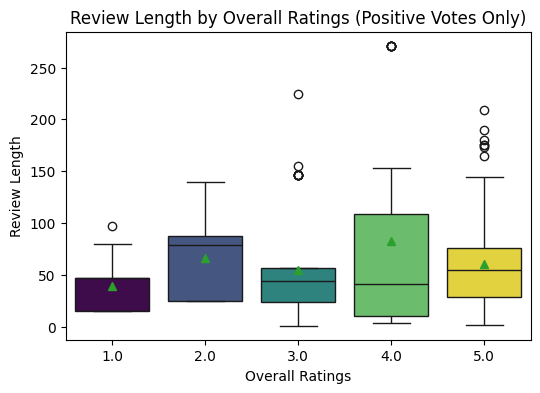

In [ ]:
# Filter rows with positive vote
positive_vote_df = data_df[data_df['vote'] > 0].copy()

# Calculate and add a new column for reviewText length (based on number of words)
positive_vote_df['reviewText_length'] = positive_vote_df['reviewText'].apply(lambda x: len(x.split(" ")))

# Filter out rows with reviewText length greater than or equal to 300
positive_vote_df = positive_vote_df[positive_vote_df['reviewText_length'] < 300].copy()

# Create a box plot for review length by overall ratings
plt.figure(figsize=(6, 4))
sns.boxplot(x='overall', y='reviewText_length', data=positive_vote_df, hue='overall',
            showmeans=True, palette='viridis', legend=False)
plt.title('Review Length by Overall Ratings (Positive Votes Only)')
plt.xlabel('Overall Ratings')
plt.ylabel('Review Length')

plt.show()

In [ ]:

# Based on the mean review length value of each box plot, the mean text lengths
# of reviews with 2.0 rating and 4.0 rating seem to be higher than the rest.
# This may show that users tend to write more to explain why the products are
# not good enough for 5.0 or not bad enough to be 1.0.

#### Task 6.2: size feedback and overall ratings

1. Create a list `size_feedback_columns` containing the size feedback categories: 'Too small', 'Somewhat small', 'Fits as expected', 'Somewhat large', 'Too large'.

2. Use `groupby` to create a DataFrame (`size_feedback_counts`) with counts for each combination of 'overall' and size feedback categories.

3. Keep only rows in `size_feedback_counts` where the sum of size feedback categories is greater than 0.

4. Create a new DataFrame (`size_feedback_percentages`) by normalizing counts to percentages along each row.

5. Create a bar plot using `df.plot` with percentages for each size feedback category across overall ratings. Set the params as `width=0.8, stacked=False, colormap='viridis'`.

6. Set a title for the plot, label the x-axis as 'Overall Ratings', and the y-axis as 'Percentage'. Set the legend with `title='Size Feedback Categories', bbox_to_anchor=(1, 1)`.

7. Write 1-2 sentences about the insight you obtained based on the observation.

<Figure size 1200x800 with 0 Axes>

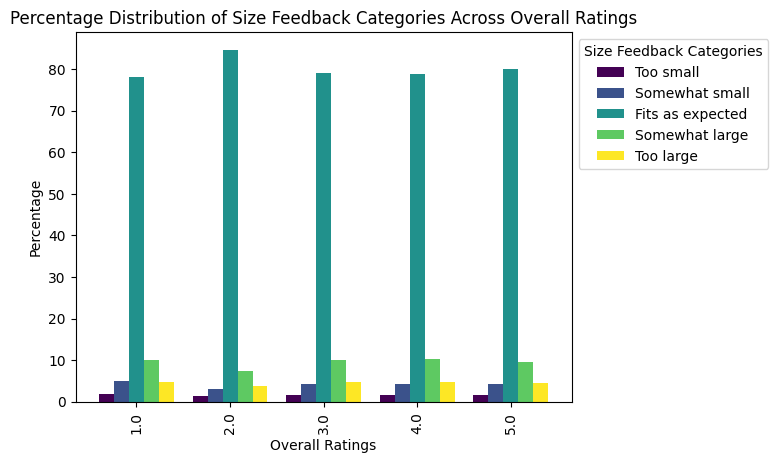

In [ ]:
# size_feedback
size_feedback_columns = ['Too small', 'Somewhat small', 'Fits as expected', 'Somewhat large', 'Too large']

# Create a DataFrame with counts for each combination of 'overall' and size feedback categories # (0.1 marks)
size_feedback_counts = data_df.groupby('overall')[size_feedback_columns].sum()

# Filter rows where the sum of size feedback categories is greater than 0
size_feedback_counts = size_feedback_counts[size_feedback_counts.sum(axis=1) > 0]

# Normalize counts to percentages along each row
size_feedback_percentages = size_feedback_counts.div(size_feedback_counts.sum(axis=1), axis=0) * 100

# Reorder columns to match the specified order
size_feedback_percentages = size_feedback_percentages[['Too small', 'Somewhat small', 'Fits as expected', 'Somewhat large', 'Too large']]

# Plot
plt.figure(figsize=(12, 8))
size_feedback_percentages.plot(kind='bar', width=0.8, stacked=False, colormap='viridis')
plt.title('Percentage Distribution of Size Feedback Categories Across Overall Ratings')
plt.xlabel('Overall Ratings')
plt.ylabel('Percentage')
plt.legend(title='Size Feedback Categories', bbox_to_anchor=(1, 1))
plt.show()

In [ ]:

# Based on the percentage of different size feedback categories across
# different review ratings, the overall distribution of size feedback
# seems to be quite similar. This may show that the size feedback is
# not the main reason for the low or high ratings.

#### Task 6.2 (adjusted): size feedback and overall ratings

1. Create a list named `size_feedback_columns` containing the size feedback categories: 'Too small', 'Somewhat small', 'Fits as expected', 'Somewhat large', and 'Too large'.

2. Use the `data_df` DataFrame to filter rows where the sum of the size feedback columns is greater than 0 (set the new dataframe as `size_feedback_data`).

3. Group the `size_feedback_data` DataFrame by the 'asin' column and calculate the mean for 'overall' rating and each size feedback column (set the new dataframe as `product_level_data`).

4. Create a new column `fit perc` in the `product_level_data` DataFrame by calculating the percentage of `Fits as expected` for each product by dividing the `Fits as expected` column by the sum of all size feedback columns for each product.

5. Create a new column `unfit perc` in the `product_level_data` DataFrame by calculating the percentage of `Too large` and `Too small` combined for each product and dividing their sum by the sum of all size feedback columns.

6. Create Two Scatter Plots Side by Side (Hint: use `plt.subplots()`):
  - Create a scatter plot on the left with 'Overall' (`overall`) on the x-axis and 'Fit Percentage' (`fit perc`) on the y-axis. Use blue color and add labels and the legend.
  - Create a scatter plot on the right with 'Overall' (`overall`) on the x-axis and 'Unfit Percentage' (`unfit perc`) on the y-axis. Use red color and add labels and a legend.

7. Write 1-2 sentences about the insight you obtained based on the observation.

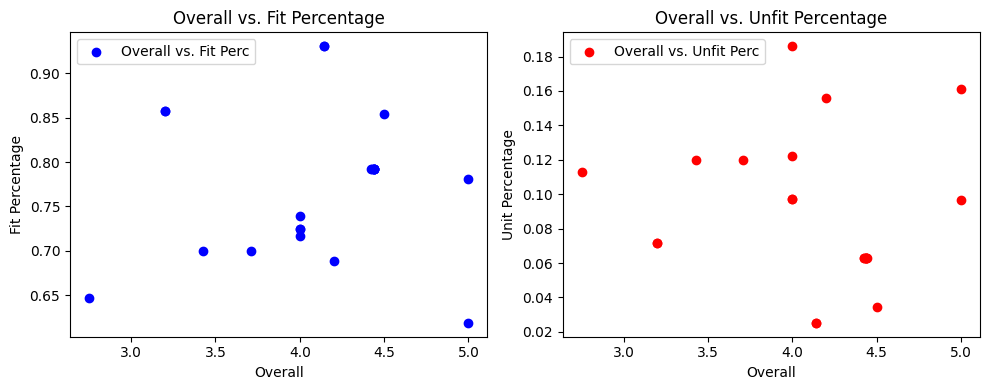

In [ ]:
# List of size feedback columns (0.1 marks)
size_feedback_columns = ['Too small', 'Somewhat small', 'Fits as expected', 'Somewhat large', 'Too large']

# Filter rows with positive sum for size feedback columns (0.1 marks)
size_feedback_data = data_df[data_df[size_feedback_columns].sum(axis=1) > 0]

# Calculate mean for 'overall' rating and size feedback columns at the product level (0.1 marks)
product_level_data = size_feedback_data.groupby('asin').agg({
    'overall': 'mean',
    'Too small': 'mean',
    'Somewhat small': 'mean',
    'Fits as expected': 'mean',
    'Somewhat large': 'mean',
    'Too large': 'mean'
}).reset_index()

# Calculate the percentage of 'Fits as expected' for each product (0.1 marks)
product_level_data['fit perc'] = product_level_data['Fits as expected'] / product_level_data[size_feedback_columns].sum(axis=1)
product_level_data['unfit perc'] = (product_level_data['Too large'] + product_level_data['Too small']) / product_level_data[size_feedback_columns].sum(axis=1)

# Create two scatter plots side by side (0.1 marks)
fig, axs = plt.subplots(1, 2, figsize=(10, 4))

# Scatter plot for Overall vs. Fit Percentage with blue color (0.1 marks)
axs[0].scatter(product_level_data['overall'], product_level_data['fit perc'], color='blue', label='Overall vs. Fit Perc')
axs[0].set_title('Overall vs. Fit Percentage')
axs[0].set_xlabel('Overall')
axs[0].set_ylabel('Fit Percentage')
axs[0].legend()

# Scatter plot for Overall vs. Unfit Percentage with red color
axs[1].scatter(product_level_data['overall'], product_level_data['unfit perc'], color='red', label='Overall vs. Unfit Perc')
axs[1].set_title('Overall vs. Unfit Percentage')
axs[1].set_xlabel('Overall')
axs[1].set_ylabel('Unit Percentage')
axs[1].legend()

plt.tight_layout()
plt.show()

In [ ]:

# The products with high overall ratings can also have lower fit percentage and
# highier unfit percentage than some low overall rating products. There might be
# other reasons that lead to the difference in ratings.

#### Task 6.3: word cloud

1. Define a function `extract_adjectives` that takes a piece of text as input, tokenizes it, performs part-of-speech tagging using `pos_tag`, and extracts adjectives (tag: "JJ").
2. Define a function `generate_word_cloud_adjectives` that takes a text, extracts adjectives, and generates a Word Cloud for visualization. Set the params as `width=800, height=400, background_color='white'`.
3. Create two variables `low_star_reviews` and `high_star_reviews` by combining all the processed_reviews for low and high ratings in `data_df` respectively (Hint: use `" ".join()`). Use thresholds overall==1 for low ratings and overall==5 for high ratings.
4. Apply the `generate_word_cloud_adjectives` function to generate Word Clouds for adjectives in `low_star_reviews` and `high_star_reviews`.
5. Observe the generated Word Clouds and analyze the adjectives used in low and high rating reviews.

In [ ]:
# Download NLTK resources for part-of-speech tagging
nltk.download('punkt')
nltk.download('averaged_perceptron_tagger')

# Define function to extract adjectives
def extract_adjectives(text):
    """
    Extracts adjectives from a given text.

    Parameters:
    - text (str): The input text from which adjectives will be extracted.

    Returns:
    - list: A list of adjectives extracted from the input text.
    """

    # Tokenize the input text
    tokens = word_tokenize(text)

    # Perform part-of-speech tagging on the tokens
    pos_tags = pos_tag(tokens) # (0.1 marks)

    # Extract adjectives based on their part-of-speech tags
    adjectives = [word for word, pos in pos_tags if pos in ["JJ"]] # (0.1 marks)

    # Return the list of extracted adjectives
    return adjectives

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


In [ ]:
# Define function to generate Word Cloud for adjectives
def generate_word_cloud_adjectives(text, title):
    """
    Generates a Word Cloud visualization for adjectives extracted from the input text.

    Parameters:
    - text (str): The input text from which adjectives will be extracted and visualized.

    Returns:
    - None: Displays the generated Word Cloud plot.
    """

    # Extract adjectives using the previously defined extract_adjectives function
    adjectives = extract_adjectives(text)

    # Create a WordCloud object with specific configurations (0.1 marks)
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(' '.join(adjectives))

    # Plot the Word Cloud (0.1 marks)
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.title(title)
    plt.axis('off')
    plt.show()

In [ ]:
import nltk
nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


True

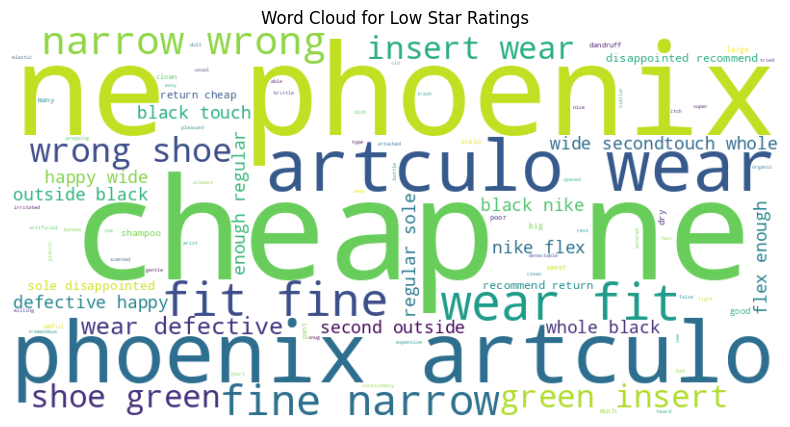

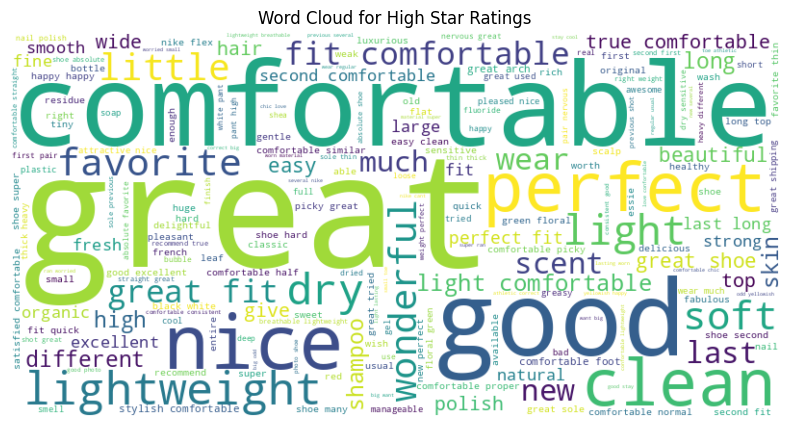

In [ ]:
# Create variables for low and high star reviews (0.1 marks)
low_star_reviews = " ".join(data_df[data_df['overall'] == 1]['processed_review'])
high_star_reviews = " ".join(data_df[data_df['overall'] == 5]['processed_review'])

# Generate Word Clouds for adjectives in low and high star reviews (0.1 marks)
generate_word_cloud_adjectives(low_star_reviews, "Word Cloud for Low Star Ratings")
generate_word_cloud_adjectives(high_star_reviews, "Word Cloud for High Star Ratings")

In [ ]:

# Words such as "comfortable", "great", "clean" have higher frequency
# in high rating reviews, while words such as "wrong shoe", "cheap" or
# "narrow" are more frequent in low rating reviews.

# Identify the Risk of Data leakage during Feature Engineering

the risk of data leakage is highly dependent on what you are predicting and how you split your data. If you are predicting **items to be purchased by an existing user**, you are dealing with a **temporal recommendation task**. In this scenario, the data leakage issues in the code become even more critical because the "future" (test set) is being used to define the "past" (training set).

Even for purchase prediction, the following issues in the source code lead to data leakage:

### 1. The "Fit" Histogram Leakage (Task 5.3)

In Task 5.3, the code extracts sizing feedback (e.g., "Too small", "Fits as expected") from the `fit` column.

* **The Issue:** In the Amazon Meta Dataset, the `fit` column is typically a **global aggregate** of all reviews received for that product up to the time the data was crawled.
* **Why it's Leakage:** If you use this aggregate fit information to predict whether a user will purchase an item today, you are including sizing feedback from reviews that haven't been written yet (the "test" period). The model effectively "sees" the future popularity or quality of an item through these aggregated counts, which it wouldn't have in a real production environment.

### 2. Global Outlier Thresholds (Task 3.1)

The code calculates the mean and standard deviation of `title_length` across the entire dataset to identify outliers.

* **The Issue:** If you are predicting future purchases, your training set should only consist of items available in the past.
* **Why it's Leakage:** By using the whole dataset, a product title in your training data might be labeled as an "outlier" (and thus removed or modified) only because it is compared against titles of new products that appear in the test set. You are cleaning your historical data using a "look-ahead" lens.

### 3. Feature Selection via Word Clouds (Tasks 6 & 7)

The code analyzes word frequencies and adjective distributions across the entire `data_df`.

* **The Issue:** If you use these word clouds to decide which keywords (like "comfortable" or "cheap") to use as features for your purchase prediction model, you are selecting features based on their prevalence in the test set.
* **Why it's Leakage:** If certain product attributes only become "trending" or frequently mentioned during the test period, your model will be artificially weighted toward those features during training, leading to a performance boost that won't hold up in real-time deployment.

### Summary for Purchase Prediction

In a purchase prediction task (especially for existing users), your pipeline must respect the **arrow of time**.

1. **Temporal Split:** You should split data by date, not randomly.
2. **Point-in-Time Features:** For Task 5.3, you would ideally need the `fit` histogram **as it existed** before the test period began. Using the final crawled version in the notebook is a classic example of **look-ahead leakage**.
3. **Local Scaling/Cleaning:** All statistics for Task 3 and Task 5 must be derived only from the "past" (training) data.